# Baseline ModelsWith the processed data ready, let's get a first read on how well the tree-based models do before any tuning. We're starting with LightGBM, XGBoost, and ExtraTrees, plus a quick look at RealMLP and TabM as a preview of what the deep learning notebook will cover.By the end of this notebook we'll have CV scores and feature importances for each baseline model, which tells us where to focus the tuning effort.

## InstallsThese packages aren't in the base environment, so we install them first.

In [ ]:
%pip install lightgbm xgboost

In [ ]:
%pip install optuna

In [ ]:
%pip install pytabkit

## Imports

In [ ]:
from pytabkit import RealMLP_TD_Classifier
from pytabkit import TabM_D_Classifier

from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import pandas as pd

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import train_pipline
from src.utils import show_confusion_matrix

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Loading the processed dataWe use the combined dataset, train plus the original SDSS17 data, for everything from here on.

In [2]:
combined_df_FE = pd.read_csv(r'..\data\processed\combined_df_FE.csv')

X = combined_df_FE.drop(['class'],axis=1)
y = combined_df_FE['class']

In [3]:
X

,alpha,delta,u,g,r,i,z,redshift,color_ug,color_gr,...,sky_x,sky_y,sky_z,z_x_u_g,z_x_g_r,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,135.689107,32.494632,23.878820,22.275300,20.395010,19.165730,18.793710,0.634794,1.603520,1.880290,...,-0.603533,0.589187,0.537221,1.017904,1.193596,0,0,1,0,1
1,144.826101,31.274185,24.777590,22.831880,22.584440,21.168120,21.614270,0.779136,1.945710,0.247440,...,-0.698632,0.492354,0.519134,1.515973,0.192789,1,0,0,0,0
2,142.188790,35.582444,25.263070,22.663890,20.609760,19.348570,18.948270,0.644195,2.599180,2.054130,...,-0.642519,0.498590,0.581874,1.674377,1.323259,0,0,1,0,1
3,338.741038,-0.402828,22.136820,23.776560,21.611620,20.504540,19.250100,0.932346,-1.639740,2.164940,...,0.931928,-0.362575,-0.007031,-1.528804,2.018472,0,0,1,0,0
4,345.282593,21.183866,19.437180,17.580280,16.497470,15.977110,15.544610,0.116123,1.856900,1.082810,...,0.901833,-0.236884,0.361362,0.215628,0.125739,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677331,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,1.974528,1.151093,...,-0.724210,-0.688194,0.043684,1.010019,0.588812,0,0,1,0,1
677332,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,1.375570,1.661308,...,-0.545742,-0.525106,0.653015,0.905936,1.094120,0,0,1,0,1
677333,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0.728394,2.189890,...,0.612052,0.790731,0.011726,0.274125,0.824148,0,0,1,0,1
677334,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,0.347115,0.635191,...,-0.243999,-0.585084,0.773396,0.995651,1.821956,0,1,0,0,0


In [4]:
X.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'color_ug',
       'color_gr', 'color_ri', 'color_iz', 'color_ur', 'color_gi', 'color_uz',
       'log1p_redshift', 'redshift_inter_ug', 'redshift_inter_gr',
       'redshift_x_z', 'stellar_locus_dist', 'qso_locus_dist',
       'quasar_color_region', 'mag_mean', 'mag_max', 'mag_min', 'mag_range',
       'alpha_sin', 'alpha_cos', 'delta_sin', 'delta_cos', 'ug_gr', 'gr_ri',
       'ri_iz', 'redshift_sq', 'redshift_low', 'redshift_mid', 'redshift_high',
       'sky_x', 'sky_y', 'sky_z', 'z_x_u_g', 'z_x_g_r', 'spectral_type_A/F',
       'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B',
       'galaxy_population_Red_Sequence'],
      dtype='str')

In [5]:
y

0         0
1         0
2         0
3         0
4         0
         ..
677331    0
677332    0
677333    0
677334    1
677335    1
Name: class, Length: 677336, dtype: int64

## Cross-validation setup5-fold stratified CV keeps the class proportions consistent across folds. The competition scores on balanced accuracy, so we'll be tracking that throughout.

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_names =['GALAXY', 'QSO', 'STAR']

## Handling class imbalanceThe classes aren't evenly split, GALAXY makes up the majority. We use SMOTE to balance them out after feature engineering, so the synthetic samples are built from the full feature set rather than just the raw magnitudes.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

Confirm the classes are now even.

In [ ]:
y_resampled.value_counts()

class
0    436922
1    436922
2    436922
Name: count, dtype: int64

## Deep learning baselines (reference only)RealMLP and TabM are slow to cross-validate on this much data, so we're leaving them commented out here and covering them properly in the deep learning notebook. The scores below are from when these were run.

In [ ]:
# Will take so long to finish
# RMLP_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,RealMLP_TD_Classifier,cv=cv)
# show_confusion_matrix(y_resampled,y_preds,target_names)
# print(classification_report(y_resampled,y_preds,target_names=target_names))

# Mean CV Accuracy: 0.97104

In [ ]:
# Will take so long to finish
# TM_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,TabM_D_Classifier,cv=cv)
# show_confusion_matrix(y_resampled,y_preds,target_names)
# print(classification_report(y_resampled,y_preds,target_names=target_names))

# Mean CV Accuracy: 0.97789

## Tree-based baselinesNow the three models we'll actually tune: ExtraTrees, LightGBM, and XGBoost, all with default parameters first.

Cross Validating with ExtraTreesClassifier Model Now...
Fold 1: 0.97562
Fold 2: 0.97551
Fold 3: 0.97551
Fold 4: 0.97546
Fold 5: 0.97532
Mean CV Accuracy: 0.97549



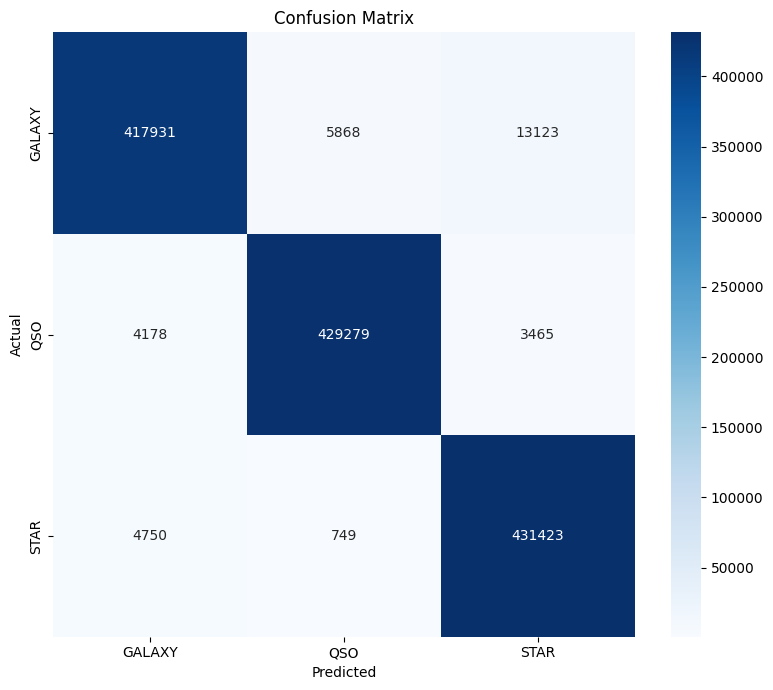

              precision    recall  f1-score   support

      GALAXY       0.98      0.96      0.97    436922
         QSO       0.98      0.98      0.98    436922
        STAR       0.96      0.99      0.98    436922

    accuracy                           0.98   1310766
   macro avg       0.98      0.98      0.98   1310766
weighted avg       0.98      0.98      0.98   1310766



In [ ]:
ET_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,ExtraTreesClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

Cross Validating with LGBMClassifier Model Now...
Fold 1: 0.97068
Fold 2: 0.97046
Fold 3: 0.97076
Fold 4: 0.97036
Fold 5: 0.97012
Mean CV Accuracy: 0.97048



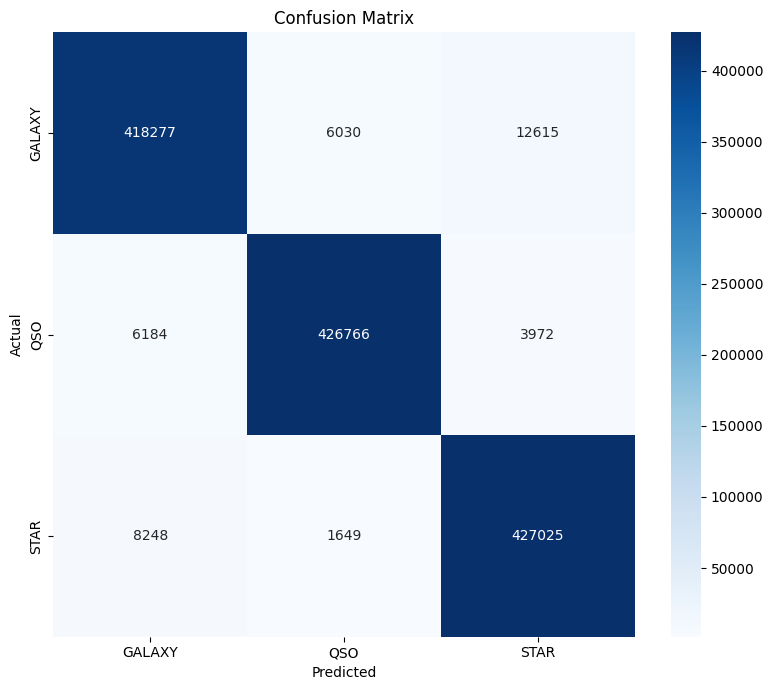

              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.96    436922
         QSO       0.98      0.98      0.98    436922
        STAR       0.96      0.98      0.97    436922

    accuracy                           0.97   1310766
   macro avg       0.97      0.97      0.97   1310766
weighted avg       0.97      0.97      0.97   1310766



In [15]:
LGBM_model,y_preds,y_probas = train_pipline(X_resampled,y_resampled,LGBMClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

Cross Validating with XGBClassifier Model Now...
Fold 1: 0.97406
Fold 2: 0.97344
Fold 3: 0.97371
Fold 4: 0.97379
Fold 5: 0.97374
Mean CV Accuracy: 0.97375



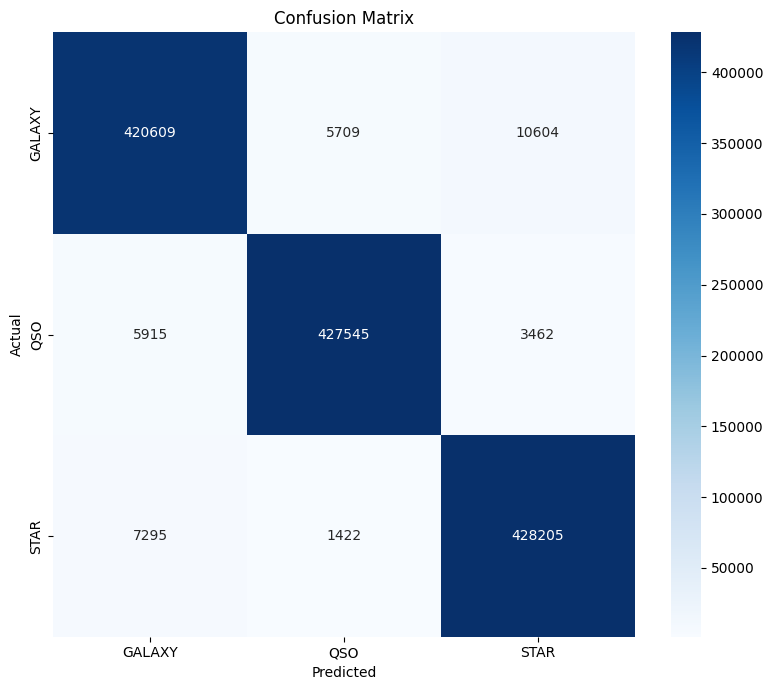

              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.97    436922
         QSO       0.98      0.98      0.98    436922
        STAR       0.97      0.98      0.97    436922

    accuracy                           0.97   1310766
   macro avg       0.97      0.97      0.97   1310766
weighted avg       0.97      0.97      0.97   1310766



In [16]:
XGB_model,y_preds, y_probas = train_pipline(X_resampled,y_resampled,XGBClassifier,cv=cv)
show_confusion_matrix(y_resampled,y_preds,target_names)
print(classification_report(y_resampled,y_preds,target_names=target_names))

## Feature importanceLet's check which features each model actually leans on. This tells us if the engineered features are pulling their weight.

In [ ]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': ET_model.feature_importances_})

fi.sort_values('importances',ascending=False)

,features,importances
36,redshift_high,0.106973
34,redshift_low,0.095945
44,spectral_type_M,0.087805
15,log1p_redshift,0.074777
7,redshift,0.062048
18,redshift_x_z,0.061549
35,redshift_mid,0.057482
21,quasar_color_region,0.041312
46,galaxy_population_Red_Sequence,0.039808
25,mag_range,0.027997


In [17]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': LGBM_model.feature_importances_})

fi.sort_values('importances',ascending=False)

,features,importances
33,redshift_sq,696
29,delta_cos,487
15,log1p_redshift,382
37,sky_x,377
27,alpha_cos,363
1,delta,346
8,color_ug,340
6,z,324
3,g,323
7,redshift,320


In [18]:
fi = pd.DataFrame({'features': X.columns,
                   'importances': XGB_model.feature_importances_})

fi.sort_values('importances',ascending=False)

,features,importances
15,log1p_redshift,0.312635
13,color_gi,0.182910
18,redshift_x_z,0.180518
12,color_ur,0.061721
3,g,0.021275
35,redshift_mid,0.018990
33,redshift_sq,0.017855
17,redshift_inter_gr,0.015580
45,spectral_type_O/B,0.015369
44,spectral_type_M,0.015328
